# SciFact Graph Model Reranker

Ноутбук проверяет не отдельный поиск с нуля, а полный сценарий:

1. тот же chunk-level baseline из третьей главы (`semantic search + graph rerank`, `w=0.05`) формирует кандидатов;
2. графовая модель обучается переупорядочивать этих кандидатов;
3. GraphSAGE, GAT и R-GCN сравниваются с baseline по одним и тем же retrieval-метрикам;
4. выполняется небольшой автоматический подбор гиперпараметров.

Структура ноутбука следует методичке: разбиение выборки, преобразование данных в граф, описание архитектур, функция ошибки и регуляризация, обучение, промежуточные и финальные метрики, проверка переобучения, сравнение трех архитектур и подбор гиперпараметров.

Зависимости:

```python
%pip install pandas matplotlib numpy torch torch-geometric sentence-transformers
```


## Подготовка

In [95]:
from __future__ import annotations

import copy
import json
import math
import random
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, RGCNConv, SAGEConv

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path.cwd() / "notebooks"

PROJECT_ROOT = NOTEBOOK_DIR.parent
PACKAGES_DIR = PROJECT_ROOT / "src" / "packages"
DATASET_DIR = NOTEBOOK_DIR / "data" / "scifact"
MODEL_CACHE_DIR = NOTEBOOK_DIR / "data" / "hf_cache"

if str(PACKAGES_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGES_DIR))

from sciguide_pipeline import SourceDocument
from sciguide_pipeline.infrastructure.processing import DeterministicEntityExtractor, LangChainTextChunker


## Конфигурация

In [109]:
SEED = 42

MAX_DOCUMENTS = None
VALIDATION_SHARE = 0.2

CHUNK_SIZE = 900
CHUNK_OVERLAP = 120
SEMANTIC_TOP_CHUNKS = 40
CANDIDATES_PER_QUERY = 50
NEGATIVES_PER_POSITIVE = 6
MAX_ENTITY_NODES = 1500

EMBEDDING_MODEL_NAME = "BAAI/bge-m3"
GRAPH_SIGNAL_WEIGHT = 0.05
VECTOR_WEIGHT = 1.0 - GRAPH_SIGNAL_WEIGHT
ENTITY_MAX_DOCUMENT_FREQUENCY_SHARE = 0.08
NEIGHBOR_SIGNAL_WEIGHT = 0.15

CANDIDATE_FEATURE_DIM = 5
DEFAULT_RESIDUAL_ALPHA = 0.10
RESIDUAL_ALPHA_GRID = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.5, 0.75, 1.0]

DEFAULT_HIDDEN_DIM = 64
DEFAULT_DROPOUT = 0.25
DEFAULT_LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 25
PATIENCE = 6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Данные и split

In [97]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file]


def load_qrels(path: Path) -> dict[str, dict[str, int]]:
    frame = pd.read_csv(path, sep="\t").rename(
        columns={"query-id": "query_id", "corpus-id": "corpus_id", "score": "relevance"}
    )
    qrels: dict[str, dict[str, int]] = defaultdict(dict)
    for row in frame.itertuples(index=False):
        qrels[str(row.query_id)][str(row.corpus_id)] = int(row.relevance)
    return dict(qrels)


def document_text(row: dict) -> str:
    return "\n\n".join(part.strip() for part in [row.get("title", ""), row.get("text", "")] if part and part.strip())


corpus_rows = load_jsonl(DATASET_DIR / "corpus.jsonl")
query_rows = load_jsonl(DATASET_DIR / "queries.jsonl")
corpus = {str(row["_id"]): row for row in corpus_rows}
queries = {str(row["_id"]): row["text"] for row in query_rows}
train_qrels = load_qrels(DATASET_DIR / "qrels" / "train.tsv")
test_qrels = load_qrels(DATASET_DIR / "qrels" / "test.tsv")

train_query_ids = list(train_qrels.keys())
random.shuffle(train_query_ids)
validation_size = int(len(train_query_ids) * VALIDATION_SHARE)
validation_query_ids = train_query_ids[:validation_size]
train_query_ids = train_query_ids[validation_size:]
test_query_ids = list(test_qrels.keys())

all_query_ids = train_query_ids + validation_query_ids + test_query_ids
all_qrels = {**train_qrels, **test_qrels}
relevant_doc_ids = {
    doc_id
    for query_id in all_query_ids
    for doc_id, rel in all_qrels.get(query_id, {}).items()
    if rel > 0
}

selected_doc_ids = list(corpus.keys()) if MAX_DOCUMENTS is None else list(sorted(relevant_doc_ids))
if MAX_DOCUMENTS is not None:
    for doc_id in corpus:
        if len(selected_doc_ids) >= MAX_DOCUMENTS:
            break
        if doc_id not in relevant_doc_ids:
            selected_doc_ids.append(doc_id)
    selected_doc_ids = selected_doc_ids[:MAX_DOCUMENTS]
selected_doc_id_set = set(selected_doc_ids)
doc_texts = {doc_id: document_text(corpus[doc_id]) for doc_id in selected_doc_ids}

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "queries": [len(train_query_ids), len(validation_query_ids), len(test_query_ids)],
        "documents_in_pool": [len(selected_doc_ids)] * 3,
    }
)

,split,queries,documents_in_pool
0,train,648,5183
1,validation,161,5183
2,test,300,5183


## Embeddings и графовый сигнал baseline

In [98]:
source_documents = [
    SourceDocument(
        content=doc_texts[doc_id],
        document_id=doc_id,
        source_name=f"scifact::{doc_id}",
        metadata={"title": corpus[doc_id].get("title", ""), "beir_doc_id": doc_id},
    )
    for doc_id in selected_doc_ids
]

chunker = LangChainTextChunker(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = chunker.chunk_documents(source_documents)
chunk_frame = pd.DataFrame(
    [
        {
            "chunk_id": chunk.id,
            "document_id": str(chunk.document_id),
            "text": chunk.text,
            "title": chunk.metadata.get("title", ""),
            "words": len(chunk.text.split()),
        }
        for chunk in chunks
    ]
)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, cache_folder=str(MODEL_CACHE_DIR), device="cpu")
query_embeddings = embedding_model.encode(
    [queries[qid] for qid in all_query_ids],
    normalize_embeddings=True,
    batch_size=8,
    show_progress_bar=True,
)
chunk_embeddings = embedding_model.encode(
    chunk_frame["text"].tolist(),
    normalize_embeddings=True,
    batch_size=8,
    show_progress_bar=True,
)

query_embedding_by_id = dict(zip(all_query_ids, np.asarray(query_embeddings, dtype=np.float32)))
chunk_embeddings = np.asarray(chunk_embeddings, dtype=np.float32)
EMBEDDING_DIM = chunk_embeddings.shape[1]

chunk_indices_by_document = {
    str(doc_id): group.index.to_numpy(dtype=int)
    for doc_id, group in chunk_frame.groupby("document_id", sort=False)
}

def normalized_mean(vectors: np.ndarray) -> np.ndarray:
    vector = vectors.mean(axis=0)
    norm = np.linalg.norm(vector)
    return vector / norm if norm else vector


document_embedding_by_id = {
    doc_id: normalized_mean(chunk_embeddings[indices]).astype(np.float32)
    for doc_id, indices in chunk_indices_by_document.items()
}

pd.DataFrame(
    {
        "object": ["documents", "chunks", "mean_chunk_words", "embedding_dim"],
        "value": [len(selected_doc_ids), len(chunk_frame), round(float(chunk_frame["words"].mean()), 2), EMBEDDING_DIM],
    }
)


Batches: 100%|██████████| 1987/1987 [28:20<00:00,  1.17it/s] 


,object,value
0,documents,5183.00
1,chunks,15893.00
2,mean_chunk_words,76.51
3,embedding_dim,1024.00


In [99]:
extractor = DeterministicEntityExtractor()
chunk_entities_raw = [tuple(extractor.extract(text)) for text in chunk_frame["text"]]
query_entities_raw = {qid: tuple(extractor.extract(queries[qid])) for qid in all_query_ids}

entity_document_frequency: Counter[str] = Counter()
for doc_id, indices in chunk_indices_by_document.items():
    doc_entities = set()
    for chunk_index in indices:
        doc_entities.update(chunk_entities_raw[chunk_index])
    entity_document_frequency.update(doc_entities)

max_entity_document_frequency = max(1, int(len(selected_doc_ids) * ENTITY_MAX_DOCUMENT_FREQUENCY_SHARE))
allowed_entities = {
    entity
    for entity, frequency in entity_document_frequency.items()
    if frequency <= max_entity_document_frequency
}
entity_idf = {
    entity: math.log(1 + len(selected_doc_ids) / (1 + entity_document_frequency[entity]))
    for entity in allowed_entities
}

chunk_entities = [tuple(entity for entity in entities if entity in allowed_entities) for entities in chunk_entities_raw]
query_entities = {
    qid: tuple(entity for entity in entities if entity in allowed_entities)
    for qid, entities in query_entities_raw.items()
}

entity_to_chunks: dict[str, set[int]] = defaultdict(set)
token_to_entities: dict[str, set[str]] = defaultdict(set)
entity_tokens: dict[str, set[str]] = {}
entity_edges = Counter()

for chunk_index, entities in enumerate(chunk_entities):
    unique_entities = list(dict.fromkeys(entities))
    for entity in unique_entities:
        entity_to_chunks[entity].add(chunk_index)
        tokens = set(extractor.extract_tokens(entity))
        entity_tokens[entity] = tokens
        for token in tokens:
            token_to_entities[token].add(entity)
    for index, left_entity in enumerate(unique_entities):
        for right_entity in unique_entities[index + 1 : index + 3]:
            entity_edges[(left_entity, right_entity)] += 1

entity_ids = [entity for entity, _ in Counter(entity for entities in chunk_entities for entity in entities).most_common(MAX_ENTITY_NODES)]
entity_id_set = set(entity_ids)

neighbors: dict[str, set[str]] = defaultdict(set)
for left_entity, right_entity in entity_edges:
    neighbors[left_entity].add(right_entity)
    neighbors[right_entity].add(left_entity)


def normalize(scores: np.ndarray) -> np.ndarray:
    if scores.size == 0:
        return scores
    min_score = float(scores.min())
    max_score = float(scores.max())
    if max_score == min_score:
        return np.ones_like(scores) if max_score else np.zeros_like(scores)
    return (scores - min_score) / (max_score - min_score)


def aggregate_chunk_scores_to_documents(chunk_scores: np.ndarray, top_chunk_count: int) -> dict[str, float]:
    top_indices = np.argsort(chunk_scores)[::-1][:top_chunk_count]
    document_scores: dict[str, float] = {}
    for chunk_index in top_indices:
        score = float(chunk_scores[chunk_index])
        if score <= 0:
            continue
        doc_id = str(chunk_frame.iloc[chunk_index]["document_id"])
        document_scores[doc_id] = max(document_scores.get(doc_id, score), score)
    return document_scores


def graph_scores_for_query(query_id: str) -> np.ndarray:
    query_text = queries[query_id]
    query_entity_tokens = set(extractor.extract_tokens(query_text))
    matched_entities = set(query_entities[query_id])
    for token in query_entity_tokens:
        matched_entities.update(token_to_entities.get(token, set()))

    expanded_entities = set(matched_entities)
    for entity in matched_entities:
        expanded_entities.update(neighbors.get(entity, set()))

    scores = np.zeros(len(chunk_entities), dtype=np.float32)
    for chunk_index, entities in enumerate(chunk_entities):
        entity_set = set(entities)
        exact_score = sum(entity_idf.get(entity, 0.0) for entity in entity_set & matched_entities)
        neighbor_score = sum(entity_idf.get(entity, 0.0) for entity in entity_set & expanded_entities if entity not in matched_entities)
        scores[chunk_index] = exact_score + NEIGHBOR_SIGNAL_WEIGHT * neighbor_score
    return scores

pd.DataFrame(
    {
        "metric": ["graph_signal_weight", "vector_weight", "raw_entities", "filtered_entities", "filtered_edges", "entity_nodes", "neighbor_signal_weight"],
        "value": [GRAPH_SIGNAL_WEIGHT, VECTOR_WEIGHT, len(entity_document_frequency), len(entity_to_chunks), len(entity_edges), len(entity_ids), NEIGHBOR_SIGNAL_WEIGHT],
    }
)


,metric,value
0,graph_signal_weight,0.05
1,vector_weight,0.95
2,raw_entities,137401.00
3,filtered_entities,137401.00
4,filtered_edges,257566.00
5,entity_nodes,1500.00
6,neighbor_signal_weight,0.15


## Кандидаты baseline и hard negatives

In [100]:
selected_doc_index = {doc_id: i for i, doc_id in enumerate(selected_doc_ids)}

semantic_document_scores_by_query: dict[str, dict[str, float]] = {}
graph_document_scores_by_query: dict[str, dict[str, float]] = {}
baseline_document_scores_by_query: dict[str, dict[str, float]] = {}
baseline_rankings: dict[str, list[str]] = {}
baseline_rank_lookup: dict[str, dict[str, int]] = {}
candidates_by_query: dict[str, list[str]] = {}


def score_components(query_id: str) -> tuple[dict[str, float], dict[str, float], dict[str, float]]:
    semantic_chunk_scores = normalize(chunk_embeddings @ query_embedding_by_id[query_id])
    graph_chunk_scores = normalize(graph_scores_for_query(query_id))
    baseline_chunk_scores = VECTOR_WEIGHT * semantic_chunk_scores + GRAPH_SIGNAL_WEIGHT * graph_chunk_scores
    return (
        aggregate_chunk_scores_to_documents(semantic_chunk_scores, SEMANTIC_TOP_CHUNKS),
        aggregate_chunk_scores_to_documents(graph_chunk_scores, SEMANTIC_TOP_CHUNKS),
        aggregate_chunk_scores_to_documents(baseline_chunk_scores, SEMANTIC_TOP_CHUNKS),
    )


for query_id in all_query_ids:
    semantic_scores, graph_scores, baseline_scores = score_components(query_id)
    semantic_document_scores_by_query[query_id] = semantic_scores
    graph_document_scores_by_query[query_id] = graph_scores
    baseline_document_scores_by_query[query_id] = baseline_scores

    ranked = [doc_id for doc_id, _ in sorted(baseline_scores.items(), key=lambda item: item[1], reverse=True)]
    baseline_rankings[query_id] = ranked[:CANDIDATES_PER_QUERY]
    candidates_by_query[query_id] = baseline_rankings[query_id]
    baseline_rank_lookup[query_id] = {doc_id: rank for rank, doc_id in enumerate(baseline_rankings[query_id], start=1)}


def candidate_features(query_id: str, doc_id: str) -> list[float]:
    rank = baseline_rank_lookup[query_id].get(doc_id, CANDIDATES_PER_QUERY + 1)
    return [
        float(semantic_document_scores_by_query[query_id].get(doc_id, 0.0)),
        float(graph_document_scores_by_query[query_id].get(doc_id, 0.0)),
        float(baseline_document_scores_by_query[query_id].get(doc_id, 0.0)),
        1.0 / rank,
        1.0 - min(rank - 1, CANDIDATES_PER_QUERY) / CANDIDATES_PER_QUERY,
    ]


def candidate_feature_tensor(query_id: str, doc_ids: list[str]) -> torch.Tensor:
    return torch.tensor([candidate_features(query_id, doc_id) for doc_id in doc_ids], dtype=torch.float32, device=device)


def candidate_baseline_scores(query_id: str, doc_ids: list[str]) -> np.ndarray:
    return np.asarray([baseline_document_scores_by_query[query_id].get(doc_id, 0.0) for doc_id in doc_ids], dtype=np.float32)


def dcg(relevances: list[float]) -> float:
    return sum(((2**rel) - 1) / math.log2(rank + 2) for rank, rel in enumerate(relevances))


def evaluate_rankings(rankings: dict[str, list[str]], query_ids: list[str], qrels: dict[str, dict[str, int]], k_values: tuple[int, ...] = (5, 10)) -> dict[str, float]:
    metrics = {f"ndcg@{k}": 0.0 for k in k_values} | {f"recall@{k}": 0.0 for k in k_values} | {f"precision@{k}": 0.0 for k in k_values} | {f"mrr@{k}": 0.0 for k in k_values}
    evaluated = 0
    for query_id in query_ids:
        relevant_docs = qrels.get(query_id, {})
        relevant_doc_ids = {doc_id for doc_id, rel in relevant_docs.items() if rel > 0}
        if not relevant_doc_ids:
            continue
        ideal_relevances = sorted(relevant_docs.values(), reverse=True)
        for k in k_values:
            top_k = rankings.get(query_id, [])[:k]
            top_k_relevances = [relevant_docs.get(doc_id, 0) for doc_id in top_k]
            hits = sum(doc_id in relevant_doc_ids for doc_id in top_k)
            ideal_dcg = dcg(ideal_relevances[:k])
            metrics[f"ndcg@{k}"] += dcg(top_k_relevances) / ideal_dcg if ideal_dcg else 0.0
            metrics[f"recall@{k}"] += hits / len(relevant_doc_ids)
            metrics[f"precision@{k}"] += hits / k
            metrics[f"mrr@{k}"] += next((1.0 / rank for rank, doc_id in enumerate(top_k, start=1) if doc_id in relevant_doc_ids), 0.0)
        evaluated += 1
    return {name: round(value / evaluated, 4) for name, value in metrics.items()}


baseline_test_metrics = {
    "model": f"Semantic + graph baseline (w={GRAPH_SIGNAL_WEIGHT:.2f})",
    "residual_alpha": 0.0,
    **evaluate_rankings(baseline_rankings, test_query_ids, test_qrels),
}
pd.DataFrame([baseline_test_metrics])


,model,residual_alpha,ndcg@5,ndcg@10,recall@5,recall@10,precision@5,precision@10,mrr@5,mrr@10
0,Semantic + graph baseline (w=0.05),0.0,0.6281,0.6537,0.7242,0.7968,0.1593,0.0897,0.6065,0.6151


## Граф для обучаемого reranker

In [101]:
entity_embeddings = embedding_model.encode(entity_ids, normalize_embeddings=True, batch_size=16, show_progress_bar=True)
entity_embedding_by_id = dict(zip(entity_ids, np.asarray(entity_embeddings, dtype=np.float32)))

node_index: dict[tuple[str, str], int] = {}
node_features: list[np.ndarray] = []


def add_node(kind: str, external_id: str, vector: np.ndarray) -> int:
    key = (kind, external_id)
    if key not in node_index:
        node_index[key] = len(node_features)
        node_features.append(np.asarray(vector, dtype=np.float32))
    return node_index[key]


for query_id in all_query_ids:
    add_node("query", query_id, query_embedding_by_id[query_id])
for doc_id in selected_doc_ids:
    add_node("document", doc_id, document_embedding_by_id[doc_id])
for row in chunk_frame.itertuples(index=True):
    add_node("chunk", str(row.Index), chunk_embeddings[row.Index])
for entity_id in entity_ids:
    add_node("entity", entity_id, entity_embedding_by_id[entity_id])

relation_to_id = {
    "query_candidate": 0,
    "candidate_query": 1,
    "document_chunk": 2,
    "chunk_document": 3,
    "chunk_entity": 4,
    "entity_chunk": 5,
    "entity_cooccurs": 6,
    "entity_cooccurs_reverse": 7,
}
edges: list[tuple[int, int]] = []
edge_types: list[int] = []


def add_edge(source: int, target: int, relation: str) -> None:
    edges.append((source, target))
    edge_types.append(relation_to_id[relation])


for query_id, doc_ids in candidates_by_query.items():
    query_node = node_index[("query", query_id)]
    for doc_id in doc_ids:
        doc_node = node_index[("document", doc_id)]
        add_edge(query_node, doc_node, "query_candidate")
        add_edge(doc_node, query_node, "candidate_query")

for row in chunk_frame.itertuples(index=True):
    doc_node = node_index[("document", str(row.document_id))]
    chunk_node = node_index[("chunk", str(row.Index))]
    add_edge(doc_node, chunk_node, "document_chunk")
    add_edge(chunk_node, doc_node, "chunk_document")

for chunk_index, entities in enumerate(chunk_entities):
    chunk_node = node_index[("chunk", str(chunk_index))]
    filtered = [entity for entity in entities if entity in entity_id_set]
    for entity in filtered:
        entity_node = node_index[("entity", entity)]
        add_edge(chunk_node, entity_node, "chunk_entity")
        add_edge(entity_node, chunk_node, "entity_chunk")
    for left, right in zip(filtered, filtered[1:]):
        add_edge(node_index[("entity", left)], node_index[("entity", right)], "entity_cooccurs")
        add_edge(node_index[("entity", right)], node_index[("entity", left)], "entity_cooccurs_reverse")

data = Data(
    x=torch.tensor(np.vstack(node_features), dtype=torch.float32),
    edge_index=torch.tensor(edges, dtype=torch.long).t().contiguous(),
    edge_type=torch.tensor(edge_types, dtype=torch.long),
).to(device)

pd.DataFrame({"metric": ["nodes", "edges", "relations"], "value": [data.num_nodes, data.num_edges, len(relation_to_id)]})


Batches: 100%|██████████| 94/94 [00:16<00:00,  5.66it/s]


,metric,value
0,nodes,23685
1,edges,127364
2,relations,8


## Train pairs из baseline-кандидатов

In [102]:
def make_pairs(query_ids: list[str], qrels: dict[str, dict[str, int]]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    pairs: list[tuple[int, int]] = []
    features: list[list[float]] = []
    labels: list[float] = []

    for query_id in query_ids:
        candidates = candidates_by_query[query_id]
        positive_set = {doc_id for doc_id, rel in qrels.get(query_id, {}).items() if rel > 0}
        positives = [doc_id for doc_id in candidates if doc_id in positive_set]
        negatives = [doc_id for doc_id in candidates if doc_id not in positive_set]
        if not positives or not negatives:
            continue

        query_node = node_index[("query", query_id)]
        hard_negatives = negatives[: NEGATIVES_PER_POSITIVE * len(positives)]
        for doc_id in positives + hard_negatives:
            pairs.append((query_node, node_index[("document", doc_id)]))
            features.append(candidate_features(query_id, doc_id))
            labels.append(float(doc_id in positive_set))

    return (
        torch.tensor(pairs, dtype=torch.long).t().contiguous().to(device),
        torch.tensor(features, dtype=torch.float32).to(device),
        torch.tensor(labels, dtype=torch.float32).to(device),
    )


train_pairs, train_pair_features, train_labels = make_pairs(train_query_ids, train_qrels)
validation_pairs, validation_pair_features, validation_labels = make_pairs(validation_query_ids, train_qrels)

pd.DataFrame(
    {
        "split": ["train", "validation"],
        "pairs": [train_labels.numel(), validation_labels.numel()],
        "positive_share": [float(train_labels.mean().cpu()), float(validation_labels.mean().cpu())],
    }
)


,split,pairs,positive_share
0,train,4636,0.144090
1,validation,1092,0.142857


## Модели

In [103]:
class LinkDecoder(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float, feature_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 4 + feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, z: torch.Tensor, pair_index: torch.Tensor, pair_features: torch.Tensor) -> torch.Tensor:
        q = z[pair_index[0]]
        d = z[pair_index[1]]
        graph_features = torch.cat([q, d, torch.abs(q - d), q * d], dim=-1)
        return self.mlp(torch.cat([graph_features, pair_features], dim=-1)).squeeze(-1)


class BaseReranker(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float, feature_dim: int = CANDIDATE_FEATURE_DIM):
        super().__init__()
        self.decoder = LinkDecoder(hidden_dim, dropout, feature_dim)

    def forward(self, graph: Data, pair_index: torch.Tensor, pair_features: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encode(graph), pair_index, pair_features)


class GraphSAGEModel(BaseReranker):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float):
        super().__init__(hidden_dim, dropout)
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def encode(self, graph: Data) -> torch.Tensor:
        x = F.relu(self.conv1(graph.x, graph.edge_index))
        return self.conv2(F.dropout(x, p=self.dropout, training=self.training), graph.edge_index)


class GATModel(BaseReranker):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float):
        super().__init__(hidden_dim, dropout)
        self.conv1 = GATConv(input_dim, hidden_dim, heads=2, concat=False, dropout=dropout)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def encode(self, graph: Data) -> torch.Tensor:
        x = F.elu(self.conv1(graph.x, graph.edge_index))
        return self.conv2(F.dropout(x, p=self.dropout, training=self.training), graph.edge_index)


class RGCNModel(BaseReranker):
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float, num_relations: int):
        super().__init__(hidden_dim, dropout)
        self.conv1 = RGCNConv(input_dim, hidden_dim, num_relations=num_relations)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.dropout = dropout

    def encode(self, graph: Data) -> torch.Tensor:
        x = F.relu(self.conv1(graph.x, graph.edge_index, graph.edge_type))
        return self.conv2(F.dropout(x, p=self.dropout, training=self.training), graph.edge_index, graph.edge_type)


## Обучение и оценка reranking

In [104]:
def model_rankings(model: nn.Module, query_ids: list[str], residual_alpha: float) -> dict[str, list[str]]:
    model.eval()
    rankings = {}
    with torch.no_grad():
        z = model.encode(data)
        for query_id in query_ids:
            doc_ids = candidates_by_query[query_id]
            pairs = torch.tensor(
                [(node_index[("query", query_id)], node_index[("document", doc_id)]) for doc_id in doc_ids],
                dtype=torch.long,
                device=device,
            ).t().contiguous()
            pair_features = candidate_feature_tensor(query_id, doc_ids)
            correction = normalize(model.decoder(z, pairs, pair_features).cpu().numpy().astype(np.float32))
            scores = candidate_baseline_scores(query_id, doc_ids) + residual_alpha * correction
            rankings[query_id] = [doc_id for _, doc_id in sorted(zip(scores, doc_ids), reverse=True)]
    return rankings


def select_residual_alpha(model: nn.Module, query_ids: list[str], qrels: dict[str, dict[str, int]]) -> tuple[float, pd.DataFrame]:
    rows = []
    for alpha in RESIDUAL_ALPHA_GRID:
        metrics = evaluate_rankings(model_rankings(model, query_ids, alpha), query_ids, qrels)
        rows.append({"residual_alpha": alpha, **metrics})
    frame = pd.DataFrame(rows).sort_values(["ndcg@10", "mrr@10"], ascending=False)
    return float(frame.iloc[0]["residual_alpha"]), frame


def train_model(model: nn.Module, name: str, lr: float, weight_decay: float) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    positives = train_labels.sum().clamp(min=1.0)
    pos_weight = ((train_labels.numel() - train_labels.sum()) / positives).clamp(min=1.0)
    best_score = -1.0
    best_state = copy.deepcopy(model.state_dict())
    bad_epochs = 0
    history = []
    started_at = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        train_loss = F.binary_cross_entropy_with_logits(model(data, train_pairs, train_pair_features), train_labels, pos_weight=pos_weight)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_loss = F.binary_cross_entropy_with_logits(
                model(data, validation_pairs, validation_pair_features),
                validation_labels,
                pos_weight=pos_weight,
            )
        validation_metrics = evaluate_rankings(
            model_rankings(model, validation_query_ids, DEFAULT_RESIDUAL_ALPHA),
            validation_query_ids,
            train_qrels,
        )
        score = validation_metrics["ndcg@10"]

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        history.append(
            {
                "model": name,
                "epoch": epoch,
                "train_loss": float(train_loss.cpu()),
                "validation_loss": float(validation_loss.cpu()),
                "loss_gap": float(validation_loss.cpu() - train_loss.cpu()),
                "elapsed_seconds": round(time.perf_counter() - started_at, 2),
                **validation_metrics,
            }
        )
        if bad_epochs >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## Сравнение трех архитектур

In [111]:
def build_model(model_name: str, hidden_dim: int, dropout: float) -> nn.Module:
    if model_name == "GraphSAGE":
        return GraphSAGEModel(EMBEDDING_DIM, hidden_dim, dropout)
    if model_name == "GAT":
        return GATModel(EMBEDDING_DIM, hidden_dim, dropout)
    if model_name == "R-GCN":
        return RGCNModel(EMBEDDING_DIM, hidden_dim, dropout, num_relations=len(relation_to_id))
    raise ValueError(model_name)


histories = []
alpha_searches = []
results = [baseline_test_metrics]
trained_models = {}
selected_alphas = {}

for model_name in ["GraphSAGE", "GAT", "R-GCN"]:
    model = build_model(model_name, DEFAULT_HIDDEN_DIM, DEFAULT_DROPOUT)
    trained_model, history = train_model(model, model_name, DEFAULT_LR, WEIGHT_DECAY)
    best_alpha, alpha_frame = select_residual_alpha(trained_model, validation_query_ids, train_qrels)

    trained_models[model_name] = trained_model
    selected_alphas[model_name] = best_alpha
    histories.append(history)
    alpha_searches.append(alpha_frame.assign(model=model_name))

    rankings = model_rankings(trained_model, test_query_ids, best_alpha)
    results.append({"model": model_name, "residual_alpha": best_alpha, **evaluate_rankings(rankings, test_query_ids, test_qrels)})

history_frame = pd.concat(histories, ignore_index=True)
alpha_search_frame = pd.concat(alpha_searches, ignore_index=True)
results_frame = pd.DataFrame(results)
results_frame


,model,residual_alpha,ndcg@5,ndcg@10,recall@5,recall@10,precision@5,precision@10,mrr@5,mrr@10
0,Semantic + graph baseline (w=0.05),0.0,0.6281,0.6537,0.7242,0.7968,0.1593,0.0897,0.6065,0.6151
1,GraphSAGE,0.1,0.6249,0.6491,0.7175,0.7861,0.1580,0.0883,0.6044,0.6126
2,GAT,0.0,0.6281,0.6537,0.7242,0.7968,0.1593,0.0897,0.6065,0.6151
3,R-GCN,0.1,0.6438,0.6720,0.7253,0.8072,0.1600,0.0907,0.6263,0.6358


## Подбор гиперпараметров

По методичке подбираются минимум три гиперпараметра. Здесь автоматический grid search выполняется по `hidden_dim`, `dropout` и `lr` для лучшей архитектуры из предыдущего сравнения.

In [110]:
model_rows = results_frame[~results_frame["model"].str.startswith("Semantic + graph baseline")]
best_model_name = model_rows.sort_values(["ndcg@10", "mrr@10"], ascending=False).iloc[0]["model"]

search_grid = [
    {"hidden_dim": 64, "dropout": 0.15, "lr": 1e-3},
    {"hidden_dim": 96, "dropout": 0.25, "lr": 1e-3},
    {"hidden_dim": 128, "dropout": 0.35, "lr": 5e-4},
]

tuning_rows = []
tuning_alpha_searches = []
for params in search_grid:
    model = build_model(best_model_name, params["hidden_dim"], params["dropout"])
    trained_model, history = train_model(model, f"{best_model_name} tuned", params["lr"], WEIGHT_DECAY)
    best_alpha, alpha_frame = select_residual_alpha(trained_model, validation_query_ids, train_qrels)
    test_metrics = evaluate_rankings(model_rankings(trained_model, test_query_ids, best_alpha), test_query_ids, test_qrels)
    tuning_rows.append(
        {
            "model": best_model_name,
            **params,
            "residual_alpha": best_alpha,
            "best_validation_ndcg@10": history["ndcg@10"].max(),
            **test_metrics,
        }
    )
    tuning_alpha_searches.append(alpha_frame.assign(model=best_model_name, **params))

tuning_frame = pd.DataFrame(tuning_rows).sort_values(["best_validation_ndcg@10", "ndcg@10"], ascending=False)
tuning_alpha_search_frame = pd.concat(tuning_alpha_searches, ignore_index=True)
tuning_frame


,model,hidden_dim,dropout,lr,residual_alpha,best_validation_ndcg@10,ndcg@5,ndcg@10,recall@5,recall@10,precision@5,precision@10,mrr@5,mrr@10
0,R-GCN,64,0.15,0.0010,0.1,0.6528,0.6491,0.6709,0.7371,0.7989,0.1627,0.0897,0.6298,0.6371
1,R-GCN,96,0.25,0.0010,0.1,0.6519,0.6521,0.6754,0.7378,0.8039,0.1633,0.0903,0.6319,0.6402
2,R-GCN,128,0.35,0.0005,0.1,0.6491,0.6499,0.6753,0.7361,0.8112,0.1633,0.0913,0.6297,0.6386


## Диагностика обучения

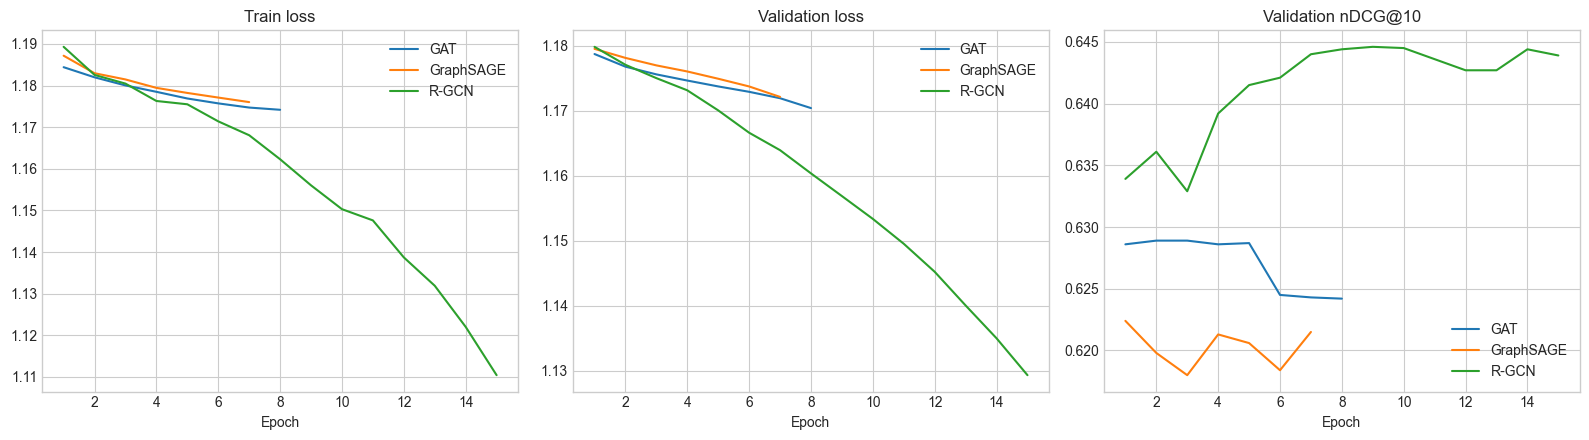

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for model_name, frame in history_frame.groupby("model"):
    axes[0].plot(frame["epoch"], frame["train_loss"], label=model_name)
    axes[1].plot(frame["epoch"], frame["validation_loss"], label=model_name)
    axes[2].plot(frame["epoch"], frame["ndcg@10"], label=model_name)

axes[0].set_title("Train loss")
axes[1].set_title("Validation loss")
axes[2].set_title("Validation nDCG@10")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.legend()

plt.tight_layout()
plt.show()

## Проверка переобучения

In [108]:
overfit_check = (
    history_frame.sort_values(["model", "ndcg@10"], ascending=[True, False])
    .groupby("model", as_index=False)
    .head(1)[["model", "epoch", "train_loss", "validation_loss", "loss_gap", "ndcg@10", "elapsed_seconds"]]
    .sort_values("ndcg@10", ascending=False)
)
overfit_check

,model,epoch,train_loss,validation_loss,loss_gap,ndcg@10,elapsed_seconds
23,R-GCN,9,1.156019,1.156841,0.000822,0.6446,6.41
8,GAT,2,1.181984,1.176755,-0.005229,0.6289,0.80
0,GraphSAGE,1,1.187175,1.179496,-0.007678,0.6224,0.98
